**Requisitos**

In [ ]:
!pip install transformers datasets peft accelerate torch

In [ ]:
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling
)
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training
)
import torch

In [5]:
from dotenv import load_dotenv
from huggingface_hub import login
import os

# Carrega o token do .env
load_dotenv()
hf_token = os.getenv("HF_TOKEN")

login(token=hf_token)
print("✅ Autenticado no Hugging Face")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✅ Autenticado no Hugging Face


**Carregar modelo pré-treinado e tokenizador**

In [ ]:
model_name = "google/gemma-3-1b-it"

tokenizer = AutoTokenizer.from_pretrained(model_name, token=hf_token)
base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    token=hf_token,
    torch_dtype=torch.bfloat16, # float32 para CPU; use bfloat16 se tiver GPU
    device_map = "auto"
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Modelo carregado: {model_name}")

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

Modelo carregado: google/gemma-3-1b-it


**Carregar Dataset**

In [ ]:
# 1. Carrega o dataset
dataset = load_dataset('json', data_files='dataset_final_divisoes.jsonl')

# 2. Verifica colunas antes da conversão
print("Colunas originais:", dataset["train"].column_names)

# 3. Cria a coluna 'text' usando o template do Gemma-it
def convert_to_hf_format(example):
    instruction = example.get('Instruction', example.get('instruction', ''))
    output = example.get('Output', example.get('output', ''))

    # Monta no formato de chat que o Gemma-it entende
    messages = [
        {"role": "user",      "content": instruction},
        {"role": "assistant", "content": output}
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False  # False porque incluímos a resposta
    )
    return {"text": text}

dataset = dataset.map(convert_to_hf_format)

# 4. Verifica se a coluna foi criada
print("Colunas após conversão:", dataset["train"].column_names)
print("\nPrimeiro exemplo text:")
print(dataset["train"][0]["text"])

# 5. Divide em treino e teste
dataset = dataset["train"].train_test_split(test_size=0.2)
print("\nDataset final:", dataset)

Generating train split: 0 examples [00:00, ? examples/s]

Colunas originais: ['Instruction', 'Output']


Map:   0%|          | 0/167 [00:00<?, ? examples/s]

Colunas após conversão: ['Instruction', 'Output', 'text']

Primeiro exemplo text:
<bos><start_of_turn>user
Quais são as partes da Alecrim utilizadas e como elas são preparadas para uso medicinal?<end_of_turn>
<start_of_turn>model
A Alecrim é uma planta herbácea, perene, aromática, amplamente cultivada. As partes utilizadas incluem folhas, flores e outros tecidos. A preparação para uso medicinal envolve a infusão das folhas em água fervida, geralmente com uma colher de sobremesa, e a aplicação topical de folhas secas ou óleo de folhas em condições de cólicas infantis, doenças da pele, candidíase e hemorróidas.<end_of_turn>


Dataset final: DatasetDict({
    train: Dataset({
        features: ['Instruction', 'Output', 'text'],
        num_rows: 133
    })
    test: Dataset({
        features: ['Instruction', 'Output', 'text'],
        num_rows: 34
    })
})


**Inferência ANTES do Fine-Tuning**

In [ ]:
def generate_response(model, tokenizer, instruction):
    """Gera resposta usando o template de chat do Gemma-it."""

    messages = [
        {"role": "user", "content": instruction}
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True  # True porque queremos a resposta
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():           # ← adicionar isso, economiza memória
        outputs = model.generate(
            **inputs,
            max_new_tokens=200,
            pad_token_id=tokenizer.eos_token_id,
            do_sample=True,
            temperature=0.7
        )

    # Remove os tokens do prompt da saída
    prompt_len = inputs["input_ids"].shape[1]
    generated_ids = outputs[0][prompt_len:]          # ← mais limpo para Qwen3
    resposta = tokenizer.decode(generated_ids, skip_special_tokens=True)
    return resposta.strip()

# Exemplo de instrução (deve existir no dataset.jsonl)

test_instruction = "Quais são os usos e formas de preparo do Alecrim?"

print("=== ANTES DO FINE-TUNING ===")
print(f"Instrução: {test_instruction}")
print(f"Resposta base: {generate_response(base_model, tokenizer, test_instruction)}")

=== ANTES DO FINE-TUNING ===
Instrução: Quais são os usos e formas de preparo do Alecrim?
Resposta base: O alecrim é uma planta com uma longa história de uso na medicina tradicional e moderna, e seus benefícios são amplamente reconhecidos. Abaixo, detalho os usos e formas de preparo do alecrim, divididos por categorias:

**1. Usos Tradicionais e Medicina:**

* **Alívio de gripes e resfriados:** Este é o uso mais conhecido. Acredita-se que o alecrim ajude a aliviar sintomas como tosse, dor de garganta, congestão nasal e febre.
* **Alívio de dores musculares e articulares:** Pode ser usado para reduzir a dor e a inflamação associadas a dores musculares, dores nas articulações e lesões.
* **Melhora da digestão:** O alecrim é usado para estimular o apetite e aliviar a indigestão, especialmente em casos de gastrite e úlceras.
* **Fort


**Configuração LORA**

In [ ]:
# A partir daqui, usaremos uma cópia do modelo base para o fine-tuning
model = base_model  # poderia também ser uma nova instância
model = prepare_model_for_kbit_training(model)

In [ ]:
# Célula auxiliar — verificar os nomes das camadas
for name, module in base_model.named_modules():
    print(name)


model
model.embed_tokens
model.layers
model.layers.0
model.layers.0.self_attn
model.layers.0.self_attn.q_proj
model.layers.0.self_attn.k_proj
model.layers.0.self_attn.v_proj
model.layers.0.self_attn.o_proj
model.layers.0.self_attn.q_norm
model.layers.0.self_attn.k_norm
model.layers.0.mlp
model.layers.0.mlp.gate_proj
model.layers.0.mlp.up_proj
model.layers.0.mlp.down_proj
model.layers.0.mlp.act_fn
model.layers.0.input_layernorm
model.layers.0.post_attention_layernorm
model.layers.0.pre_feedforward_layernorm
model.layers.0.post_feedforward_layernorm
model.layers.1
model.layers.1.self_attn
model.layers.1.self_attn.q_proj
model.layers.1.self_attn.k_proj
model.layers.1.self_attn.v_proj
model.layers.1.self_attn.o_proj
model.layers.1.self_attn.q_norm
model.layers.1.self_attn.k_norm
model.layers.1.mlp
model.layers.1.mlp.gate_proj
model.layers.1.mlp.up_proj
model.layers.1.mlp.down_proj
model.layers.1.mlp.act_fn
model.layers.1.input_layernorm
model.layers.1.post_attention_layernorm
model.layers

In [ ]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    !pip install --upgrade torchao>=0.16.0

lora_config = LoraConfig(
    r=8,                    # rank da decomposição
    lora_alpha=16,           # escala alpha
    target_modules=[         # camadas alvo
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
    ],
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM",
    inference_mode=False     # False = modo treinamento
)

model = prepare_model_for_kbit_training(base_model)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 1,490,944 || all params: 1,001,376,896 || trainable%: 0.1489


**Tokenização**

In [ ]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

tokenized_datasets = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=dataset["train"].column_names  # remove colunas de texto
    )

# Formato PyTorch
tokenized_datasets.set_format("torch")

print("Dataset tokenizado:", tokenized_datasets)
print(f"\nColunas finais: {tokenized_datasets['train'].column_names}")

Map:   0%|          | 0/133 [00:00<?, ? examples/s]

Map:   0%|          | 0/34 [00:00<?, ? examples/s]

Dataset tokenizado: DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 133
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 34
    })
})

Colunas finais: ['input_ids', 'attention_mask']


**Data Collator**

In [ ]:
# Configura o data collator para linguagem causal
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

print("✅ Data Collator configurado")

✅ Data Collator configurado


**Argumentos de treinamento**

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./gemma_plantas_finetuned",

    # Épocas - com 167 exemplos, 3-4 é o limite
    num_train_epochs=3,

    # Batch size - conservador
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,  # Batch efetivo = 8

    # Learning rate - menor para modelo pequeno
    learning_rate=3e-4,
    warmup_ratio=0.1,               # Mais warmup para dataset pequeno
    lr_scheduler_type="cosine",
    weight_decay=0.05,              # Mais regularização

    # Avaliação - por época (não por steps)
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    # Logging
    logging_steps=10,
    logging_dir="./logs",

    # Otimização
    fp16=False,                     # Gemma prefere bf16
    bf16=True,                      # Se sua GPU suportar
    gradient_checkpointing=True,    # Economiza VRAM
    optim="adamw_torch_fused",

    # Outros
    report_to="none",               # Evita wandb/tensorboard se não quiser
    save_total_limit=2,             # Mantém só 2 checkpoints
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


**Iniciar o trainer**

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=data_collator,
)

print("✅ Trainer configurado")
print(f"   Amostras de treino:    {len(tokenized_datasets['train'])}")
print(f"   Amostras de validação: {len(tokenized_datasets['test'])}")
print(f"   Épocas:                {training_args.num_train_epochs}")

✅ Trainer configurado
   Amostras de treino:    133
   Amostras de validação: 34
   Épocas:                3


**Treinar modelo**

In [ ]:
# Célula — Fix para erro de VideoReader
import sys

# Remove o módulo problemático para evitar o erro de importação
if 'torchvision' in sys.modules:
    del sys.modules['torchvision']

# Reinstala versões compatíveis
!pip install -q --upgrade datasets
!pip install -q torchvision --extra-index-url https://download.pytorch.org/whl/cu118

# Reimporta o que precisa
from datasets import load_dataset
import torch

print("✅ Dependências corrigidas")
print(f"✅ Torch: {torch.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 22.6 MB/s eta 0:00:00
✅ Dependências corrigidas
✅ Torch: 2.11.0+cu128


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,4.167022,2.868662
2,2.473096,2.317762
3,2.132311,2.233322


/usr/local/lib/python3.12/dist-packages/peft/utils/other.py:1419: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-6a2ac3f6-1b27417514886c5f010e84cc;3d995f1a-d1b9-4bee-9584-dad938825ba4)

Cannot access gated repo for url https://huggingface.co/google/gemma-3-1b-it/resolve/main/config.json.
Access to model google/gemma-3-1b-it is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in google/gemma-3-1b-it.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:372: UserWarning: Could not find a config file in google/gemma-3-1b-it - will assume that the vocabulary was not modified.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/other.py:1419: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-6a2ac471-1346a0004c9ed1bb0e7381c4;d32043ff-33

TrainOutput(global_step=51, training_loss=2.7938113516452265, metrics={'train_runtime': 367.7, 'train_samples_per_second': 1.085, 'train_steps_per_second': 0.139, 'total_flos': 428629119270912.0, 'train_loss': 2.7938113516452265, 'epoch': 3.0})

**Gráfico de treinamento**

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def extrair_logs(trainer):
    """Extrai training loss e validation loss do histórico do Trainer."""

    logs = trainer.state.log_history

    train_steps, train_losses = [], []
    eval_steps, eval_losses = [], []

    for entry in logs:
        # Training loss
        if "loss" in entry and "eval_loss" not in entry:
            train_steps.append(entry["step"])
            train_losses.append(entry["loss"])

        # Validation loss
        if "eval_loss" in entry:
            eval_steps.append(entry["step"])
            eval_losses.append(entry["eval_loss"])

    return train_steps, train_losses, eval_steps, eval_losses

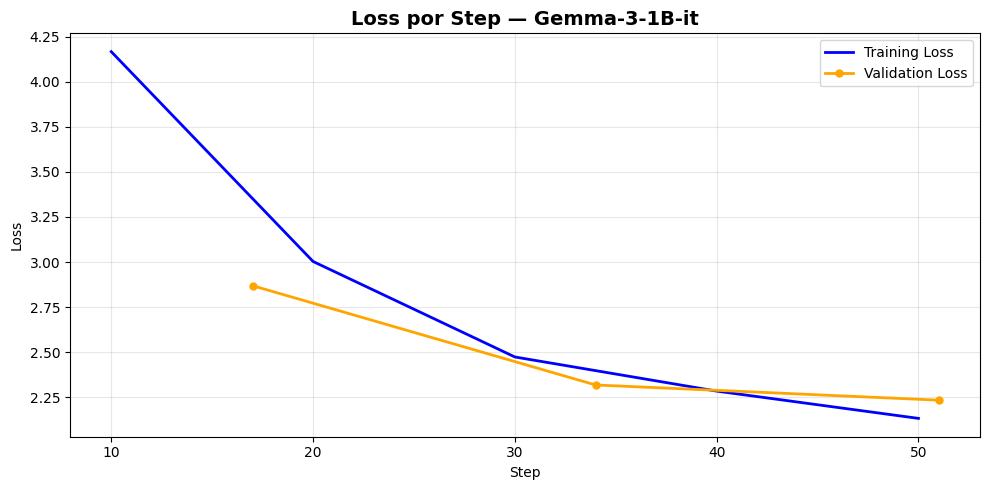

✅ Gráfico salvo como loss_Gemma-3-1B-it.png


In [ ]:
def plotar_loss(trainer, nome_modelo):
    """Plota training loss e validation loss de um modelo."""

    train_steps, train_losses, eval_steps, eval_losses = extrair_logs(trainer)

    plt.figure(figsize=(10, 5))

    plt.plot(train_steps, train_losses,
             label="Training Loss",
             color="blue",
             linewidth=2)

    if eval_losses:
        plt.plot(eval_steps, eval_losses,
                 label="Validation Loss",
                 color="orange",
                 linewidth=2,
                 marker="o",
                 markersize=5)

    plt.title(f"Loss por Step — {nome_modelo}", fontsize=14, fontweight="bold")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"loss_{nome_modelo.replace(' ', '_')}.png", dpi=150)
    plt.show()
    print(f"✅ Gráfico salvo como loss_{nome_modelo.replace(' ', '_')}.png")

# Uso após treinar cada modelo
plotar_loss(trainer, "Gemma-3-1B-it")

**Salvar modelo**

In [ ]:
model.save_pretrained("lora_causal_model_2/")
tokenizer.save_pretrained("gemma-3-1b-it_tokenizer")

/usr/local/lib/python3.12/dist-packages/peft/utils/other.py:1419: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-6a2ac4ed-26978f9236c0a805069ccce6;438378e2-2023-4c65-9291-8234c3ef0150)

Cannot access gated repo for url https://huggingface.co/google/gemma-3-1b-it/resolve/main/config.json.
Access to model google/gemma-3-1b-it is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in google/gemma-3-1b-it.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:372: UserWarning: Could not find a config file in google/gemma-3-1b-it - will assume that the vocabulary was not modified.
  warnings.warn(


('gemma-3-1b-it_tokenizer/tokenizer_config.json',
 'gemma-3-1b-it_tokenizer/chat_template.jinja',
 'gemma-3-1b-it_tokenizer/tokenizer.json')

**Inferência APÓS o Fine-Tuning**

In [ ]:
# Carrega o modelo fine-tunado (apenas os adaptadores LoRA)
finetuned_model = AutoModelForCausalLM.from_pretrained("lora_causal_model_2/")
finetuned_tokenizer = AutoTokenizer.from_pretrained("gemma-3-1b-it_tokenizer")

# Garante que o token de padding esteja definido
if finetuned_tokenizer.pad_token is None:
    finetuned_tokenizer.pad_token = finetuned_tokenizer.eos_token

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

In [ ]:
print("=== DEPOIS DO FINE-TUNING ===")
print(f"Instrução: {test_instruction}")
print(f"Resposta ajustada: {generate_response(finetuned_model, finetuned_tokenizer, test_instruction)}")

=== DEPOIS DO FINE-TUNING ===
Instrução: Quais são os usos e formas de preparo do Alecrim?
Resposta ajustada: O Alecrim possui usos terapêuticos e preparações tradicionais em diversas formas e concentrações. Além disso, são utilizadas formas de preparo como infusão, decocção e infusão em banhos e até na forma de compressas.
